In [1]:
# ==========================================================
# STEP 1: Mount Google Drive
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ==========================================================
# STEP 2: Install tfswin (Keras-compatible Swin Transformer implementation)
# ==========================================================
!pip install tfswin -q

In [3]:
# ==========================================================
# STEP 3: Verify required files exist in Drive
# ==========================================================
import os

split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

print("split_dataset.zip exists:", os.path.exists(split_zip_path))
print("csv zip exists:", os.path.exists(csv_zip_path))

split_dataset.zip exists: True
csv zip exists: True


In [4]:
# ==========================================================
# STEP 4: Copy and extract the split dataset (images)
# ==========================================================
import shutil
import zipfile

shutil.copy(split_zip_path, '/content/split_dataset.zip')

with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Image dataset extracted!")

Image dataset extracted!


In [5]:
# ==========================================================
# STEP 5: Extract the CSV zip
# ==========================================================
with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/csv_data')

for root, dirs, files in os.walk('/content/csv_data'):
    for f in files:
        print(os.path.join(root, f))

/content/csv_data/thesis_dataset_csv/test_data.csv
/content/csv_data/thesis_dataset_csv/val_data.csv
/content/csv_data/thesis_dataset_csv/train_data.csv


In [6]:
# ==========================================================
# STEP 6: Load CSVs and fix the file paths
# ==========================================================
import pandas as pd

train_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/train_data.csv')
val_df   = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
test_df  = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')

for df in [train_df, val_df, test_df]:
    df['filepath'] = df['filepath'].str.replace(
        '/content/split_dataset', '/content'
    )

print("Sample file exists:", os.path.exists(train_df['filepath'].iloc[0]))
print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))

Sample file exists: True
Train samples: 18037
Val samples: 2519
Test samples: 2538


In [7]:
# ==========================================================
# STEP 7: Build tf.data pipelines (uint8 output, required by Swin)
# ==========================================================
import tensorflow as tf

class_names = sorted(train_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # reduce to 16 if you hit GPU memory issues, Swin is heavier than CNNs

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    # Swin expects raw pixel values as uint8, not float32
    img = tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8)
    return img, label

def make_dataset(df, shuffle=False):
    filepaths = df['filepath'].values
    labels = df['label'].map(label_to_index).values
    labels = tf.keras.utils.to_categorical(labels, num_classes=num_classes)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print("Classes:", class_names)
print("Num classes:", num_classes)

Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']
Num classes: 12


In [8]:
# ==========================================================
# STEP 8 (corrected): Build Swin Transformer Tiny model
# ==========================================================
from tfswin import SwinTransformerTiny224
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(224, 224, 3), dtype='uint8')

base_model = SwinTransformerTiny224(include_top=False)
base_model.trainable = False  # Freeze for Phase 1

x = base_model(inputs)
# Swin backbone (include_top=False) returns a spatial feature map (7x7x768),
# not a pooled vector — flatten it with global average pooling first.
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

177485300/177485300 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_tiny_224 (Functional)      │ (None, 7, 7, 768)      │    27,519,354 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,719,302 (105.74 MB)

 Trainable params: 199,948 (781.05 KB)

 Non-trainable params: 27,519,354 (104.98 MB)

In [9]:
# ==========================================================
# STEP 9: Set up callbacks
# ==========================================================
backup_folder = '/content/drive/MyDrive/thesis_swintiny_outputs'
os.makedirs(backup_folder, exist_ok=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f'{backup_folder}/best_swintiny_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
)
callbacks = [early_stop, checkpoint, reduce_lr]

In [10]:
# ==========================================================
# STEP 10: Phase 1 training — train only the new top layers
# ==========================================================
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 181s 247ms/step - accuracy: 0.8577 - loss: 0.4048 - val_accuracy: 0.9428 - val_loss: 0.1574 - learning_rate: 0.0010
Epoch 2/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 87s 155ms/step - accuracy: 0.9250 - loss: 0.2048 - val_accuracy: 0.9496 - val_loss: 0.1330 - learning_rate: 0.0010
Epoch 3/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 86s 153ms/step - accuracy: 0.9387 - loss: 0.1644 - val_accuracy: 0.9551 - val_loss: 0.1284 - learning_rate: 0.0010
Epoch 4/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 141s 151ms/step - accuracy: 0.9446 - loss: 0.1450 - val_accuracy: 0.9551 - val_loss: 0.1158 - learning_rate: 0.0010
Epoch 5/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 86s 152ms/step - accuracy: 0.9504 - loss: 0.1341 - val_accuracy: 0.9647 - val_loss: 0.1113 - learning_rate: 0.0010
Epoch 6/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 85s 151ms/step - accuracy: 0.9551 - loss: 0.1223 - val_accuracy: 0.9639 - val_loss: 0.0988 - learning_rate: 0.0010
Epoch 7/10
564/564 ━━━━━━━━━━━━━━━━━━━━ 96s 170ms/step - accuracy: 0

In [11]:
# ==========================================================
# STEP 11: Phase 2 training — fine-tune the last blocks of Swin
# ==========================================================
base_model.trainable = True

# Freeze all but the last few transformer blocks (Swin has fewer, larger blocks than CNNs)
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 551s 828ms/step - accuracy: 0.9722 - loss: 0.0760 - val_accuracy: 0.9750 - val_loss: 0.0739 - learning_rate: 1.0000e-05
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 428s 680ms/step - accuracy: 0.9787 - loss: 0.0551 - val_accuracy: 0.9794 - val_loss: 0.0752 - learning_rate: 1.0000e-05
Epoch 3/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 381s 675ms/step - accuracy: 0.9840 - loss: 0.0464 - val_accuracy: 0.9774 - val_loss: 0.0779 - learning_rate: 1.0000e-05
Epoch 4/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 381s 675ms/step - accuracy: 0.9855 - loss: 0.0390 - val_accuracy: 0.9790 - val_loss: 0.0701 - learning_rate: 1.0000e-05
Epoch 5/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 383s 679ms/step - accuracy: 0.9881 - loss: 0.0322 - val_accuracy: 0.9821 - val_loss: 0.0642 - learning_rate: 1.0000e-05
Epoch 6/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 383s 679ms/step - accuracy: 0.9900 - loss: 0.0288 - val_accuracy: 0.9837 - val_loss: 0.0688 - learning_rate: 1.0000e-05
Epoch 7/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
# ==========================================================
# STEP 12: Evaluate on test set
# ==========================================================
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

with open(f'{backup_folder}/test_results.txt', 'w') as f:
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")

print("Test results saved to Drive!")

80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 287ms/step - accuracy: 0.9823 - loss: 0.0667
Test Loss: 0.0667
Test Accuracy: 0.9823
Test results saved to Drive!


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

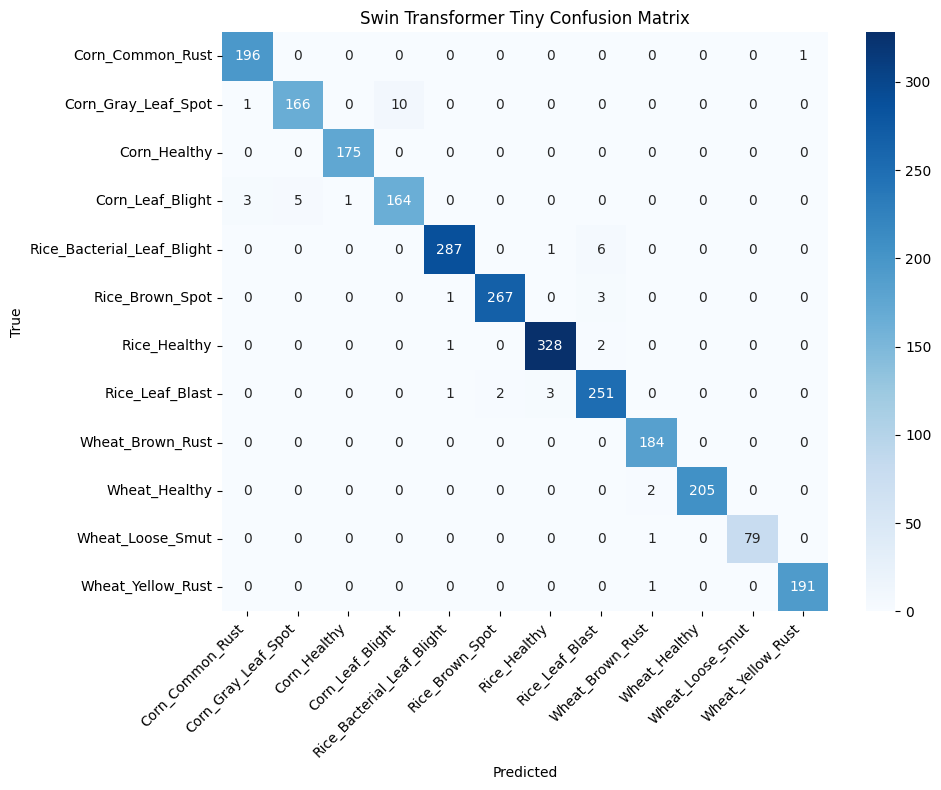

In [13]:
# ==========================================================
# STEP 13: Classification report and confusion matrix
# ==========================================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open(f'{backup_folder}/classification_report.txt', 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Swin Transformer Tiny Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{backup_folder}/confusion_matrix.png')
plt.show()

In [14]:
# ==========================================================
# STEP 14: Model size, parameters, and inference time
# ==========================================================
import os
import time

tf.get_logger().setLevel('ERROR')

model_path = f'{backup_folder}/best_swintiny_model.keras'
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

total_params = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)

dummy_input = np.random.randint(0, 256, (1, 224, 224, 3), dtype=np.uint8)
_ = model(dummy_input, training=False)  # warm-up

times = []
for _ in range(100):
    start = time.time()
    _ = model(dummy_input, training=False)
    times.append((time.time() - start) * 1000)

avg_inference_time = np.mean(times)

print("=" * 60)
print("SUMMARY FOR COMPARISON TABLE")
print("=" * 60)
print(f"Model size (MB):       {model_size_mb:.2f}")
print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {int(trainable_params):,}")
print(f"Inference time (ms):   {avg_inference_time:.2f}")

SUMMARY FOR COMPARISON TABLE
Model size (MB):       317.77
Total parameters:      27,719,302
Trainable parameters:  27,719,302
Inference time (ms):   543.14


Saving Wheat_Yellow_Rust411.jpg to Wheat_Yellow_Rust411.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


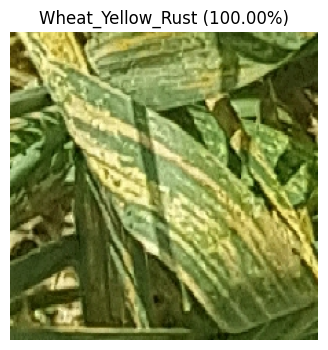

Predicted class: Wheat_Yellow_Rust
Confidence: 100.00%

Top 3 predictions:
  Wheat_Yellow_Rust: 100.00%
  Wheat_Brown_Rust: 0.00%
  Wheat_Loose_Smut: 0.00%


In [15]:
# ==========================================================
# Single image prediction with confidence (Swin Transformer Tiny)
# ==========================================================
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Upload image from your computer
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load and preprocess
# Note: Swin expects raw uint8 pixel values (0-255), not float32/normalized
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img).astype(np.uint8)
img_array = np.expand_dims(img_array, axis=0)

# Predict
preds = model.predict(img_array)
pred_index = np.argmax(preds[0])
pred_class = class_names[pred_index]
confidence = preds[0][pred_index] * 100

# Display image with prediction
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"{pred_class} ({confidence:.2f}%)")
plt.show()

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence:.2f}%")

# Show top-3 predictions for extra context
top3_idx = np.argsort(preds[0])[::-1][:3]
print("\nTop 3 predictions:")
for idx in top3_idx:
    print(f"  {class_names[idx]}: {preds[0][idx]*100:.2f}%")